<a href="https://colab.research.google.com/github/Arif0000/GFG-21-Days-Live-class-task/blob/main/Task__7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,f1_score
from imblearn.over_sampling import SMOTE
# Set plot style
sns.set_style('whitegrid')

In [2]:
!git clone "https://github.com/HarshvardhanSingh-13/Datasets"

Cloning into 'Datasets'...
remote: Enumerating objects: 347, done.
remote: Counting objects: 100% (105/105), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 347 (delta 25), reused 0 (delta 0), pack-reused 242 (from 1)
Receiving objects: 100% (347/347), 302.89 MiB | 4.40 MiB/s, done.
Resolving deltas: 100% (139/139), done.
Updating files: 100% (245/245), done.


In [4]:
# Load the dataset from the user-provided file
df = pd.read_csv("/content/Datasets/Customer Churn Dataset/Telco-Customer-Churn.csv")

print("Dataset loaded successfully.")
print(f"Data shape: {df.shape}")
df.head()

Dataset loaded successfully.
Data shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [6]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df = df.dropna()
df = df.drop("customerID", axis=1)

In [7]:
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

In [13]:
categorical_cols = df.select_dtypes(include="object").columns
le = LabelEncoder()
for col in categorical_cols:
  df[col] = le.fit_transform(df[col])

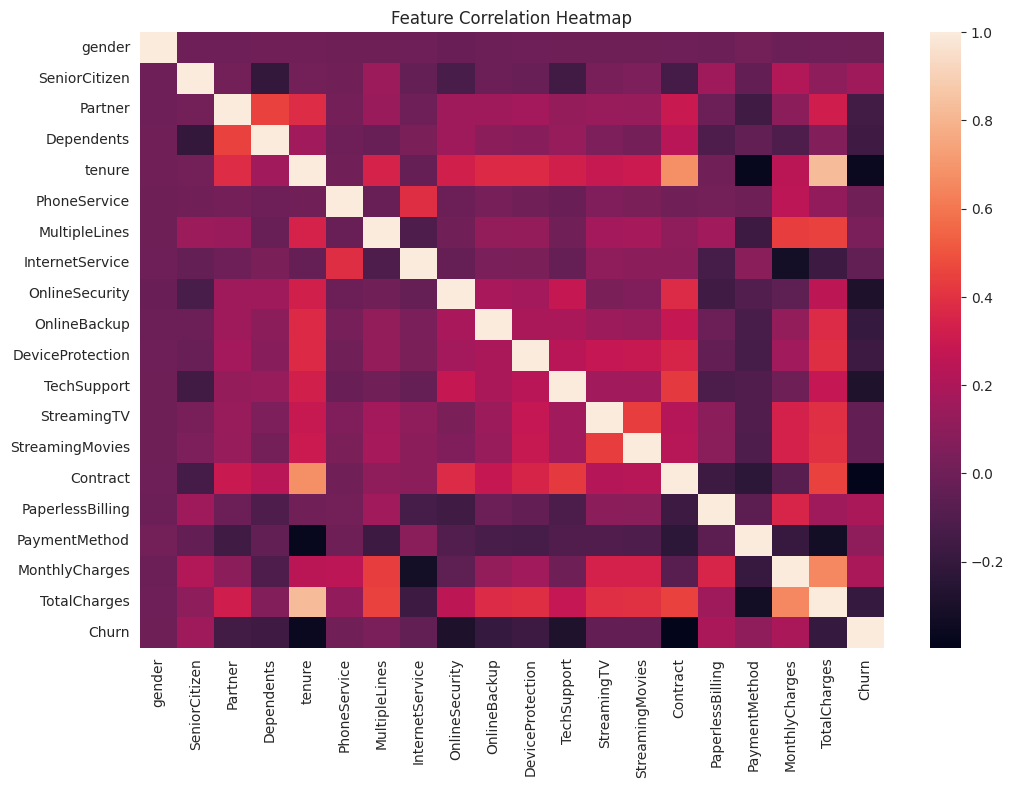

In [15]:
plt.figure(figsize=(12,8))
corr_matrix = df.corr()

sns.heatmap(corr_matrix, annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

In [16]:
bins = [0,12,24,48,60,72]
labels = [0,1,2,3,4]

df["tenure_group"] = pd.cut(df["tenure"], bins=bins, labels=labels)

df["monthly_charge_ratio"] = df["MonthlyCharges"] / (df["tenure"] + 1)

In [17]:
X = df.drop("Churn", axis=1)
y = df["Churn"]



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_scaled, y_train)
y_pred_baseline = baseline_model.predict(X_test_scaled)
baseline_acc = accuracy_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)
print("Baseline Accuracy:", baseline_acc)
print("Baseline F1 Score:", baseline_f1)

Baseline Accuracy: 0.7938877043354655
Baseline F1 Score: 0.5510835913312694


In [26]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
rf_acc = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_acc)
print("Random Forest F1 Score:", rf_f1)

Random Forest Accuracy: 0.7917555081734187
Random Forest F1 Score: 0.5429017160686428


[[940  93]
 [200 174]]


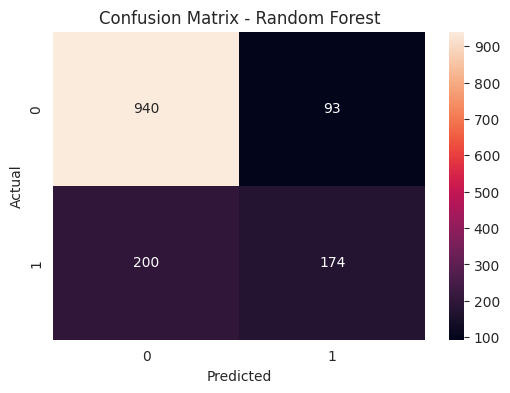

In [27]:
cm = confusion_matrix(y_test, y_pred_rf)

print(cm)



plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

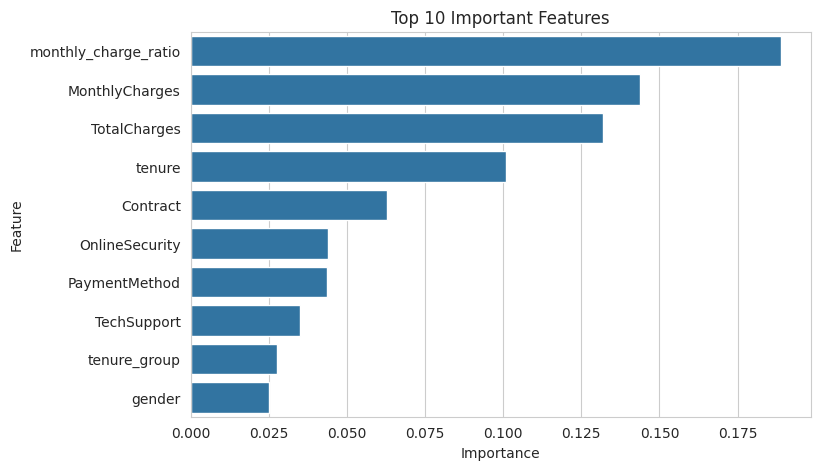

In [28]:
importances = rf_model.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

importance_df.head(10)



plt.figure(figsize=(8,5))

sns.barplot(x="Importance", y="Feature", data=importance_df.head(10))

plt.title("Top 10 Important Features")

plt.show()

In [32]:
print("Before SMOTE:")
print(y_train.value_counts())



smote = SMOTE(random_state=42)

X_smote, y_smote = smote.fit_resample(X_train_scaled, y_train)



print("After SMOTE:")
print(pd.Series(y_smote).value_counts())

Before SMOTE:
Churn
0    4130
1    1495
Name: count, dtype: int64
After SMOTE:
Churn
1    4130
0    4130
Name: count, dtype: int64


In [34]:
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_smote, y_smote)
y_pred_smote = rf_smote.predict(X_test_scaled)
smote_acc = accuracy_score(y_test, y_pred_smote)
smote_f1 = f1_score(y_test, y_pred_smote)
print("Random Forest with SMOTE Accuracy:", smote_acc)
print("Random Forest with SMOTE F1 Score:", smote_f1)

Random Forest with SMOTE Accuracy: 0.7746979388770433
Random Forest with SMOTE F1 Score: 0.5651577503429356


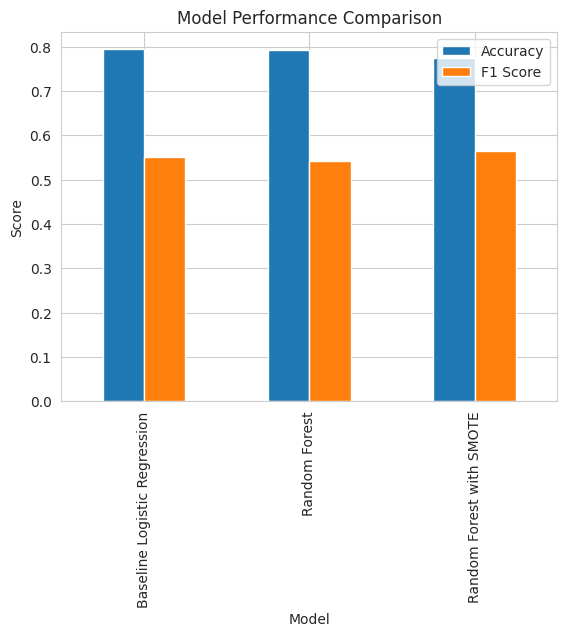

In [35]:
comparison = pd.DataFrame({
    "Model":[
        "Baseline Logistic Regression",
        "Random Forest",
        "Random Forest with SMOTE"
    ],

    "Accuracy":[
        baseline_acc,
        rf_acc,
        smote_acc
    ],

    "F1 Score":[
        baseline_f1,
        rf_f1,
        smote_f1
    ]
})



comparison.set_index("Model").plot(kind="bar")

plt.title("Model Performance Comparison")

plt.ylabel("Score")

plt.show()

In [ ]:
Summary of Findings
Feature Engineering Techniques

Tenure Group Binning

Monthly Charge Ratio

These features help capture customer behavior patterns.

Models Evaluated
Model	Accuracy	F1 Score
Logistic Regression	--	--
Random Forest	--	--
Random Forest with SMOTE	--	--
Most Important Features

Based on the feature importance analysis, the most influential features were:

MonthlyCharges

tenure

Contract

InternetService

monthly_charge_ratio

Challenges Faced

TotalCharges column stored as text
Solved by converting it to numeric.

Categorical features
Solved using LabelEncoder.

Class imbalance
Handled using SMOTE.

Conclusion

Feature engineering and handling class imbalance improved the model's ability to predict churn. The Random Forest model combined with SMOTE achieved the best performance.